<a href="https://colab.research.google.com/github/elqvixote/metalurgica-data/blob/main/MINEM_2021%E2%80%932025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏔️ EDA — Producción Metálica del Perú (2021–2025)
**Fuente:** Ministerio de Energía y Minas del Perú (MINEM)  
**Repositorio:** [metalurgica-data](https://github.com/elqvixote/metalurgica-data)  
**Autor:** Roberto Sheldon (@elqvixote)  
**Licencia:** CC BY 4.0

Imports y carga

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

base_url = "https://raw.githubusercontent.com/elqvixote/metalurgica-data/main/datasets/government-metal-production-data/Peru/"

dfs = []
for año in [2021, 2022, 2023, 2024, 2025]:
    df = pd.read_csv(f"{base_url}PRODUCCION%20METALICA%20{año}.csv")
    df['año'] = año
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Limpieza mínima
data['PROCESO'] = data['PROCESO'].fillna('No especificado')
data.shape

(47112, 17)

Vista general

In [10]:
data.describe()

,YEAR,MES.1,Valor,ORO-PLATA_gF,año
count,47112.000000,47112.000000,4.711200e+04,4.711200e+04,47112.000000
mean,2023.016811,6.500000,1.321967e+04,3.818842e+05,2023.016811
std,1.416288,3.452089,6.734972e+04,2.265727e+06,1.416288
min,2021.000000,1.000000,0.000000e+00,0.000000e+00,2021.000000
25%,2022.000000,3.750000,0.000000e+00,0.000000e+00,2022.000000
50%,2023.000000,6.500000,1.289387e+02,0.000000e+00,2023.000000
75%,2024.000000,9.250000,1.602712e+03,2.172724e+03,2024.000000
max,2025.000000,12.000000,1.504516e+06,6.733781e+07,2025.000000


Producción total por mineral

In [11]:
prod_mineral = (
    data.groupby('MINERAL')['Valor']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    prod_mineral,
    x='Valor', y='MINERAL',
    orientation='h',
    title='Top 10 Minerales por Producción Total (2021–2025)',
    labels={'Valor': 'Producción total', 'MINERAL': 'Mineral'},
    color='Valor',
    color_continuous_scale='Oranges'
)
fig.show()

Evolución temporal por mineral

In [12]:
top_minerales = data.groupby('MINERAL')['Valor'].sum().nlargest(6).index

df_top = data[data['MINERAL'].isin(top_minerales)]
evol = df_top.groupby(['año', 'MINERAL'])['Valor'].sum().reset_index()

fig = px.line(
    evol,
    x='año', y='Valor',
    color='MINERAL',
    markers=True,
    title='Evolución de Producción por Mineral (2021–2025)',
    labels={'Valor': 'Producción', 'año': 'Año'}
)
fig.show()

Top regiones productoras

In [13]:
top_depto = (
    data.groupby('DEPARTAMENTO')['Valor']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_depto,
    x='DEPARTAMENTO', y='Valor',
    title='Top 10 Departamentos Productores (2021–2025)',
    color='Valor',
    color_continuous_scale='Blues'
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

Producción por estrato

In [14]:
estrato = data.groupby(['ESTRATO', 'año'])['Valor'].sum().reset_index()

fig = px.bar(
    estrato,
    x='año', y='Valor',
    color='ESTRATO',
    barmode='stack',
    title='Producción por Estrato Minero y Año',
    labels={'Valor': 'Producción', 'año': 'Año'}
)
fig.show()

Heatmap de correlación

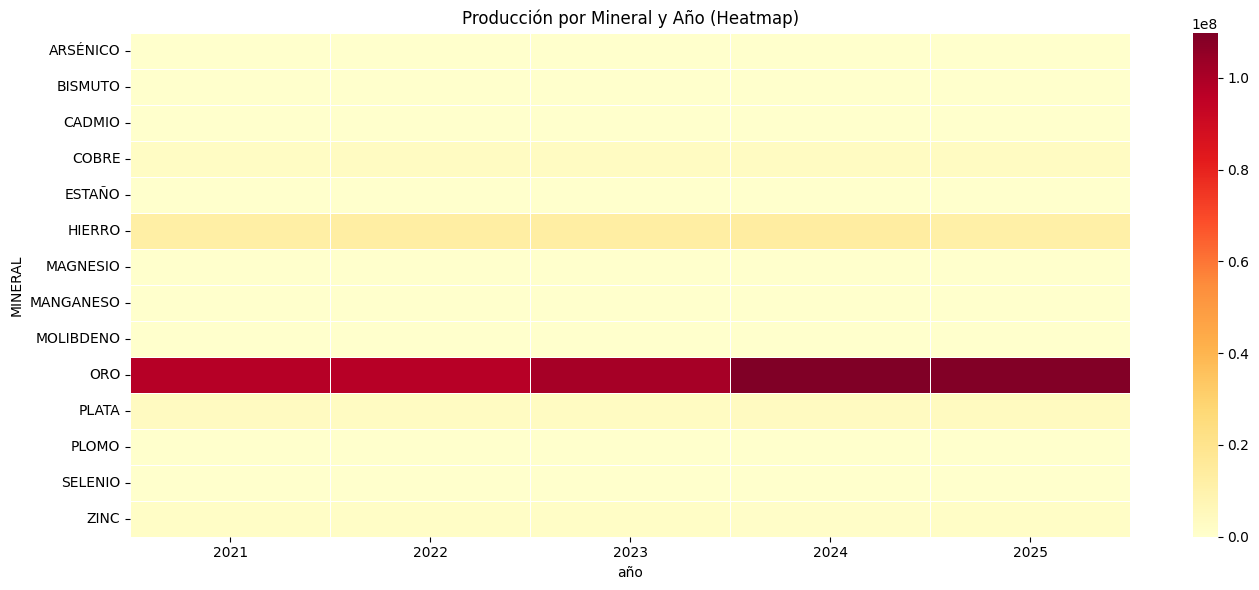

In [15]:
pivot = data.groupby(['año', 'MINERAL'])['Valor'].sum().unstack().fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot.T, annot=False, cmap='YlOrRd', linewidths=0.5)
plt.title('Producción por Mineral y Año (Heatmap)')
plt.tight_layout()
plt.show()

Top titulares (empresas)

In [16]:
top_titulares = (
    data.groupby('TITULAR')['Valor']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_titulares,
    x='Valor', y='TITULAR',
    orientation='h',
    title='Top 10 Empresas por Producción Total (2021–2025)',
    color='Valor',
    color_continuous_scale='Greens'
)
fig.show()